# SkinCare AI — MobileNetV2 Transfer Learning

## Objective

This notebook uses MobileNetV2, a pre-trained convolutional neural network, to classify skin disease images.

The main objectives are:
- Use MobileNetV2 pre-trained on ImageNet
- Apply transfer learning
- Add custom classification layers for the selected skin disease classes
- Train the model on the dermatological dataset
- Evaluate the model using accuracy, loss, classification report and confusion matrix
- Compare the results with previous CNN models

MobileNetV2 is used because training CNN models from scratch showed limited performance on this dataset.

In [40]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.metrics import classification_report, confusion_matrix

In [41]:
print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


## Dataset Path

The dataset is loaded from Kaggle input.  
The selected classes are Acne, Eczema, Psoriasis and Rosacea.

In [42]:
DATASET_PATH = "/kaggle/input/datasets/pacificrm/skindiseasedataset/SkinDisease/SkinDisease"

TRAIN_DIR = os.path.join(DATASET_PATH, "train")
TEST_DIR = os.path.join(DATASET_PATH, "test")

print("Train exists:", os.path.exists(TRAIN_DIR))
print("Test exists:", os.path.exists(TEST_DIR))

Train exists: True
Test exists: True


In [43]:
SELECTED_CLASSES = [
    "Acne",
    "Eczema",
    "Psoriasis",
    "Rosacea"
]

NUM_CLASSES = len(SELECTED_CLASSES)

print("Selected classes:", SELECTED_CLASSES)
print("Number of classes:", NUM_CLASSES)

Selected classes: ['Acne', 'Eczema', 'Psoriasis', 'Rosacea']
Number of classes: 4


## Data Preprocessing

For MobileNetV2, images are resized to 224 × 224 pixels.

Unlike the simple CNN models, MobileNetV2 uses a specific preprocessing function called `preprocess_input`.  
This function transforms image pixels into the format expected by the pre-trained MobileNetV2 model.

Training images are augmented to improve generalization, while validation and test images are only preprocessed.

In [44]:
IMG_SIZE = 224
BATCH_SIZE = 32
SEED = 42
EPOCHS = 15

In [45]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True,
    fill_mode="nearest"
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    classes=SELECTED_CLASSES,
    class_mode="categorical",
    subset="training",
    shuffle=True,
    seed=SEED
)

val_generator = val_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    classes=SELECTED_CLASSES,
    class_mode="categorical",
    subset="validation",
    shuffle=False,
    seed=SEED
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    classes=SELECTED_CLASSES,
    class_mode="categorical",
    shuffle=False
)

Found 2143 images belonging to 4 classes.
Found 534 images belonging to 4 classes.
Found 293 images belonging to 4 classes.


In [46]:
print("Class indices:")
print(train_generator.class_indices)

Class indices:
{'Acne': 0, 'Eczema': 1, 'Psoriasis': 2, 'Rosacea': 3}


## MobileNetV2 Transfer Learning

MobileNetV2 is a lightweight CNN architecture pre-trained on ImageNet.

In this experiment, MobileNetV2 is used as a feature extractor.  
The original classification layers are removed and replaced with new layers adapted to the four selected skin disease classes.

During the first training phase, the MobileNetV2 base model is frozen, and only the new classification layers are trained.

In [47]:
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.4)(x)
output = Dense(NUM_CLASSES, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=output)

In [48]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,468 (9.24 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## Training Callbacks

EarlyStopping is used to stop training when validation loss stops improving.  
ReduceLROnPlateau reduces the learning rate when validation loss stagnates.

These callbacks help improve training stability and reduce overfitting.

In [49]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=2,
    min_lr=1e-7,
    verbose=1
)

## Phase 1 — Training the Classification Head

In this phase, the MobileNetV2 base model is frozen.  
Only the custom classification layers are trained.

This allows the model to learn how to map MobileNetV2 visual features to the selected skin disease classes.

In [50]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=[early_stop, reduce_lr]
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
67/67 ━━━━━━━━━━━━━━━━━━━━ 47s 575ms/step - accuracy: 0.3353 - loss: 1.5445 - val_accuracy: 0.5543 - val_loss: 1.0618 - learning_rate: 1.0000e-04
Epoch 2/15
67/67 ━━━━━━━━━━━━━━━━━━━━ 28s 414ms/step - accuracy: 0.4962 - loss: 1.0926 - val_accuracy: 0.6067 - val_loss: 0.9860 - learning_rate: 1.0000e-04
Epoch 3/15
67/67 ━━━━━━━━━━━━━━━━━━━━ 28s 415ms/step - accuracy: 0.5432 - loss: 0.9993 - val_accuracy: 0.6105 - val_loss: 0.9372 - learning_rate: 1.0000e-04
Epoch 4/15
67/67 ━━━━━━━━━━━━━━━━━━━━ 28s 415ms/step - accuracy: 0.6087 - loss: 0.9165 - val_accuracy: 0.6105 - val_loss: 0.9199 - learning_rate: 1.0000e-04
Epoch 5/15
67/67 ━━━━━━━━━━━━━━━━━━━━ 28s 412ms/step - accuracy: 0.6436 - loss: 0.8570 - val_accuracy: 0.6142 - val_loss: 0.9111 - learning_rate: 1.0000e-04
Epoch 6/15
67/67 ━━━━━━━━━━━━━━━━━━━━ 28s 420ms/step - accuracy: 0.6387 - loss: 0.8137 - val_accuracy: 0.6217 - val_loss: 0.8928 - learning_rate: 1.0000e-04
Epoch 7/15
67/67 ━━━━━━━━━━━━━━━━━━━━ 28s 419ms/step - acc

## Learning Curves — Transfer Learning

The learning curves show the evolution of training and validation accuracy/loss during the first phase of transfer learning.

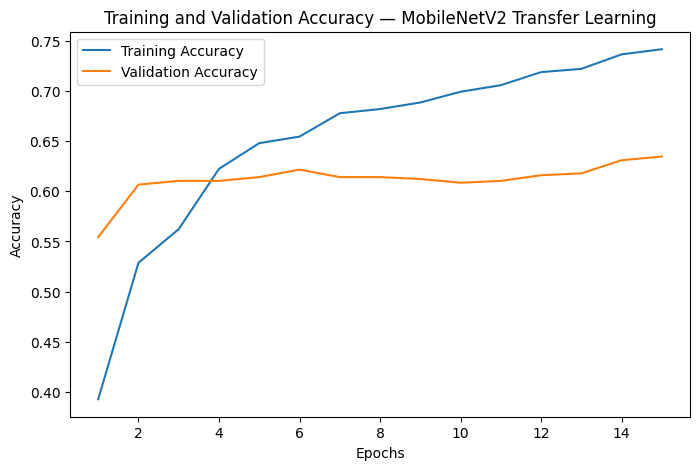

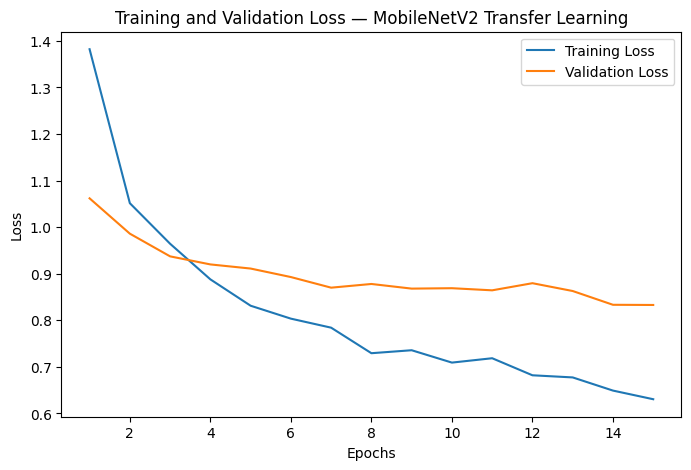

In [51]:
def plot_learning_curves(history, title_suffix=""):
    acc = history.history["accuracy"]
    val_acc = history.history["val_accuracy"]
    loss = history.history["loss"]
    val_loss = history.history["val_loss"]

    epochs_range = range(1, len(acc) + 1)

    plt.figure(figsize=(8, 5))
    plt.plot(epochs_range, acc, label="Training Accuracy")
    plt.plot(epochs_range, val_acc, label="Validation Accuracy")
    plt.title(f"Training and Validation Accuracy {title_suffix}")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(epochs_range, loss, label="Training Loss")
    plt.plot(epochs_range, val_loss, label="Validation Loss")
    plt.title(f"Training and Validation Loss {title_suffix}")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

plot_learning_curves(history, "— MobileNetV2 Transfer Learning")

In [52]:
test_loss, test_accuracy = model.evaluate(test_generator)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 462ms/step - accuracy: 0.7475 - loss: 0.6454
Test Loss: 0.7024152874946594
Test Accuracy: 0.7064846158027649


In [53]:
y_pred_prob = model.predict(test_generator)
y_pred = np.argmax(y_pred_prob, axis=1)

y_true = test_generator.classes

print("Predicted labels:", y_pred[:10])
print("True labels:", y_true[:10])

10/10 ━━━━━━━━━━━━━━━━━━━━ 9s 535ms/step
Predicted labels: [0 0 0 0 0 0 1 2 0 0]
True labels: [0 0 0 0 0 0 0 0 0 0]


In [54]:
class_labels = list(test_generator.class_indices.keys())

report = classification_report(
    y_true,
    y_pred,
    target_names=class_labels
)

print(report)

              precision    recall  f1-score   support

        Acne       0.81      0.77      0.79        65
      Eczema       0.65      0.81      0.73       112
   Psoriasis       0.68      0.51      0.58        88
     Rosacea       0.81      0.75      0.78        28

    accuracy                           0.71       293
   macro avg       0.74      0.71      0.72       293
weighted avg       0.71      0.71      0.70       293



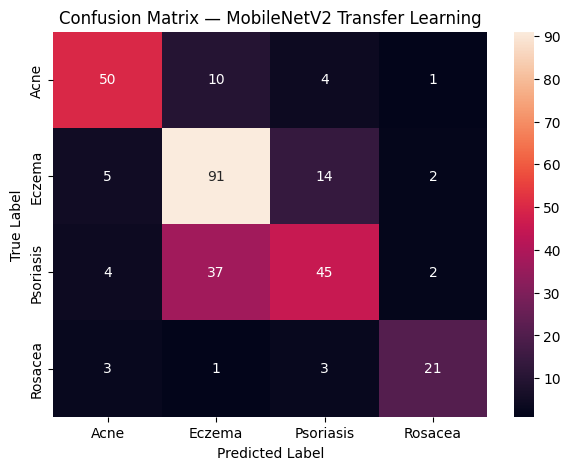

In [55]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_labels,
    yticklabels=class_labels
)

plt.title("Confusion Matrix — MobileNetV2 Transfer Learning")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

## Phase 1 Results Interpretation

The MobileNetV2 transfer learning model achieved a test accuracy of 71%, which is the best result obtained so far compared to the CNN models trained from scratch.

The model performed well on Acne and Rosacea, with F1-scores of 0.79 and 0.78 respectively. Eczema also achieved a good F1-score of 0.73. Psoriasis obtained the lowest F1-score of 0.58, indicating that this class remains the most difficult to distinguish, probably due to visual similarities with other skin conditions.

Compared to the simple CNN and the improved CNN, MobileNetV2 provides better generalization because it uses pre-trained visual features learned from a large image dataset.

Therefore, the MobileNetV2 model obtained after the first transfer learning phase is selected as the best model for this project.

In [56]:
model.save("/kaggle/working/mobilenetv2_phase1_best_model.keras")
print("Best MobileNetV2 Phase 1 model saved successfully.")

Best MobileNetV2 Phase 1 model saved successfully.


In [57]:
import json

class_indices = train_generator.class_indices

with open("/kaggle/working/class_indices.json", "w") as f:
    json.dump(class_indices, f)

print("Class indices saved successfully.")

Class indices saved successfully.


## Phase 2 — Fine-Tuning

After training the classification head, a light fine-tuning step is applied.

In this phase, only the last layers of MobileNetV2 are unfrozen.  
This allows the model to slightly adapt the pre-trained visual features to the dermatological image dataset.

A very small learning rate is used to avoid destroying the pre-trained weights.

In [33]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,468 (9.24 MB)

 Trainable params: 1,690,884 (6.45 MB)

 Non-trainable params: 731,584 (2.79 MB)

In [34]:
fine_tune_epochs = 8

history_fine = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=fine_tune_epochs,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/8
67/67 ━━━━━━━━━━━━━━━━━━━━ 59s 647ms/step - accuracy: 0.5126 - loss: 1.0980 - val_accuracy: 0.5824 - val_loss: 0.9508 - learning_rate: 1.0000e-05
Epoch 2/8
67/67 ━━━━━━━━━━━━━━━━━━━━ 28s 414ms/step - accuracy: 0.6476 - loss: 0.8412 - val_accuracy: 0.5618 - val_loss: 1.0342 - learning_rate: 1.0000e-05
Epoch 3/8
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 394ms/step - accuracy: 0.6910 - loss: 0.7384
Epoch 3: ReduceLROnPlateau reducing learning rate to 2.9999999242136253e-06.
67/67 ━━━━━━━━━━━━━━━━━━━━ 28s 423ms/step - accuracy: 0.6910 - loss: 0.7384 - val_accuracy: 0.5674 - val_loss: 1.0638 - learning_rate: 1.0000e-05
Epoch 4/8
67/67 ━━━━━━━━━━━━━━━━━━━━ 29s 426ms/step - accuracy: 0.6999 - loss: 0.7116 - val_accuracy: 0.5655 - val_loss: 1.0592 - learning_rate: 3.0000e-06
Epoch 5/8
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 391ms/step - accuracy: 0.7053 - loss: 0.7252
Epoch 5: ReduceLROnPlateau reducing learning rate to 8.999999636216671e-07.
67/67 ━━━━━━━━━━━━━━━━━━━━ 28s 418ms/step - accuracy: 0.7053 - 

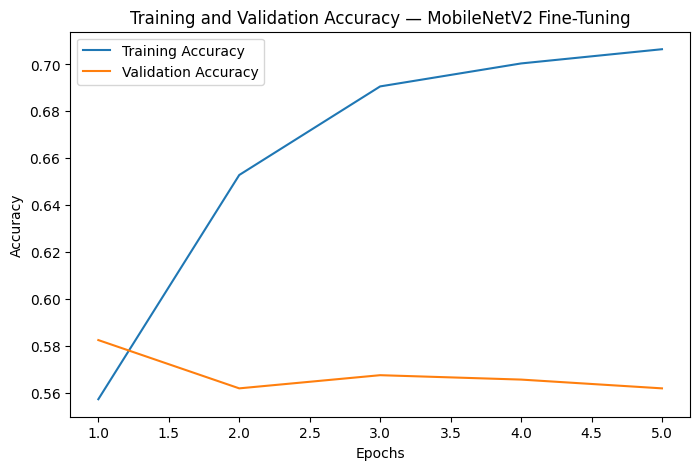

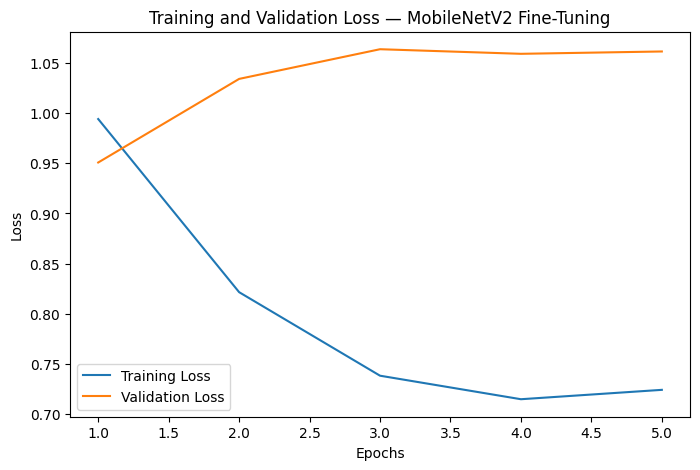

In [35]:
plot_learning_curves(history_fine, "— MobileNetV2 Fine-Tuning")

In [36]:
final_test_loss, final_test_accuracy = model.evaluate(test_generator)

print("Final Test Loss:", final_test_loss)
print("Final Test Accuracy:", final_test_accuracy)

10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 451ms/step - accuracy: 0.7532 - loss: 0.6024
Final Test Loss: 0.7585666179656982
Final Test Accuracy: 0.6689419746398926


In [37]:
y_pred_prob = model.predict(test_generator)
y_pred = np.argmax(y_pred_prob, axis=1)

y_true = test_generator.classes

10/10 ━━━━━━━━━━━━━━━━━━━━ 9s 551ms/step


In [38]:
final_report = classification_report(
    y_true,
    y_pred,
    target_names=class_labels
)

print(final_report)

              precision    recall  f1-score   support

        Acne       0.73      0.83      0.78        65
      Eczema       0.61      0.82      0.70       112
   Psoriasis       0.76      0.32      0.45        88
     Rosacea       0.73      0.79      0.76        28

    accuracy                           0.67       293
   macro avg       0.71      0.69      0.67       293
weighted avg       0.69      0.67      0.65       293



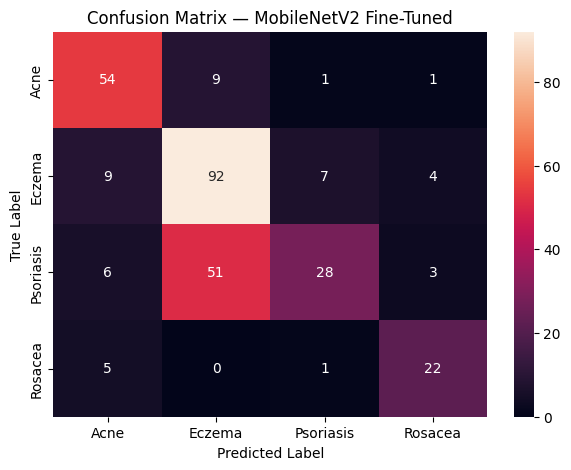

In [39]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_labels,
    yticklabels=class_labels
)

plt.title("Confusion Matrix — MobileNetV2 Fine-Tuned")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

## Final Results Interpretation and Model Selection

The MobileNetV2 model was trained using transfer learning in two phases.

In the first phase, the MobileNetV2 convolutional base was frozen, and only the newly added classification layers were trained on the selected skin disease dataset. This phase achieved the best performance, with a test accuracy of 71%, a macro F1-score of 0.72 and a weighted F1-score of 0.70.

In the second phase, fine-tuning was applied by unfreezing the last layers of the pre-trained MobileNetV2 model and training them using a small learning rate. However, the fine-tuned model did not improve the overall performance compared to the first transfer learning phase.

The Phase 1 MobileNetV2 model performed well on Acne and Rosacea, with F1-scores of 0.79 and 0.78 respectively. Eczema also achieved a good F1-score of 0.73. Psoriasis remained the most difficult class, with an F1-score of 0.58, probably due to visual similarities with other skin conditions.

Compared with the previous CNN models, MobileNetV2 achieved the best performance:

| Model | Test Accuracy | Observation |
|---|---:|---|
| Simple CNN | 51.88% | Baseline model, overfitting observed |
| Improved CNN with Dropout and Batch Normalization | 24.23% | Poor generalization, biased predictions |
| MobileNetV2 Transfer Learning — Phase 1 | 71% | Best model |
| MobileNetV2 Fine-Tuning | 67% | Slightly lower than Phase 1 |

Therefore, the best model selected for this project is the MobileNetV2 model obtained after the first transfer learning phase, without fine-tuning.